In [3]:
import requests
import pandas as pd
import textstat
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np

c:\Users\anush\anaconda3main\envs\steering\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
v_steering = np.load("v_steering.npy")

v_torch = torch.tensor(v_steering, dtype=torch.float16).to("cuda")

print("Vector shape:", v_torch.shape)

Vector shape: torch.Size([2560])


In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True
)

model.eval()

c:\Users\anush\anaconda3main\envs\steering\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 453/453 [00:16<00:00, 27.43it/s, Materializing param=model.layers.31.self_attn.v_proj.weight]
The tied weights mapping and config for this model specifies to tie model.layers.31.self_attn.q_proj.weight to model.layers.31.self_attn.q_proj.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.layers.31.self_attn.q_proj.weight to 

PhiForCausalLM(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_layernorm): LayerNorm((2560,), eps=1

In [6]:
def measure_hidden_norm():
    inputs = tokenizer("Test sentence.", return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)
    h = outputs.hidden_states[16]
    return torch.norm(h, dim=-1).mean().item()

hidden_norm = measure_hidden_norm()
print("Hidden norm:", hidden_norm)

scale_fraction = 0.1  # 10% (you can tune 0.05–0.2)
v_scaled = v_torch * (hidden_norm * scale_fraction)

print("Scaled vector norm:", torch.norm(v_scaled).item())

Hidden norm: 482.0
Scaled vector norm: 48.1875


In [7]:
scale_fraction = 0.05  # safer, stable

v_scaled = v_torch * (hidden_norm * scale_fraction)

print("Scaled vector norm:", torch.norm(v_scaled).item())

Scaled vector norm: 24.09375


In [8]:
def make_hook(alpha):
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
            rest = output[1:]

            steered = hidden_states - alpha * v_scaled
            return (steered, *rest)
        else:
            return output - alpha * v_scaled

    return hook

In [9]:
def generate_with_steering(prompt, alpha=0.0, max_new_tokens=120):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    input_len = inputs["input_ids"].shape[1]

    hook = model.model.layers[16].register_forward_hook(make_hook(alpha))

    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=tokenizer.eos_token_id
            )
    finally:
        hook.remove()

    # 🔥 ONLY decode generated part
    generated_tokens = output[0][input_len:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True)

In [15]:
def clean_output(text):
    stop_tokens = [
        "Exercise", "Question", "Solution:",
        "\n\n\n"
    ]

    for tok in stop_tokens:
        if tok in text:
            text = text.split(tok)[0]

    return text.strip()

In [14]:
import textstat

def readability(text):
    return (
        textstat.flesch_reading_ease(text),
        textstat.flesch_kincaid_grade(text)
    )

In [12]:
print(readability("This is a simple sentence."))

(83.32000000000004, 2.879999999999999)


In [13]:
def make_prompt(text):
    return f"""Explain the following text in your own words.

Text:
{text}

The explanation is:"""

In [ ]:
LEVELS = {
    "beginner": -2.0,
    "intermediate": 0.0,
    "expert": 2.0
}

In [11]:
INPUT_TEXTS = [
    "Endometriosis associated with massive ascites and absence of pelvic peritoneum. Although massive ascites associated with endometriosis has been reported in rare cases, this patient was also noted to have massive destruction of the pelvic peritoneum. Failure of medical suppression necessitated total abdominal hysterectomy and bilateral salpingo-oophorectomy. Several months after surgery ascites resolved, possibly with reestablishment of the pelvic peritoneum. ",
    "Ultrasound-Doppler diagnosis of Budd-Chiari syndrome. We report a case of apparently idiopathic Budd-Chiari syndrome, diagnosed by ultrasound and Doppler sonography, in a patient with latent myeloproliferative disease. This case proves that Doppler sonography shows in the hepatic veins a flow pattern suggestive of partial thrombotic obstruction. Moreover, we suggest that the search for a latent myeloproliferative disorder, by means of the spontaneous erythroid colonies formation in culture of bone marrow or blood mononuclear cells, should be routinely included in the diagnostic evaluation of each case of hepatic vein thrombosis without other recognizable causes. ",
    "Neurogenic inflammation of the rat trachea: fate of neutrophils that adhere to venules. The goal of this study was to determine whether neutrophils that adhere to the vascular endothelium in association with neurogenic inflammation in the respiratory tract migrate out of the blood vessels or whether they detach and reenter the circulation. We also sought to determine whether the fate of the neutrophils is influenced by neutral endopeptidase (NEP), an enzyme that degrades the tachykinins that produce neurogenic inflammation. Neutrophils in the tracheal mucosa of anesthetized pathogen-free rats were examined 5 min or 4 h after neurogenic inflammation was produced by an injection of capsaicin (100 or 200 micrograms/kg iv). In whole mounts of these tracheae stained histochemically for myeloperoxidase, adherent intravascular neutrophils had a spherical or teardrop (regular) shape and migrating neutrophils had a polarized amoeboid (irregular) shape. The number of regular neutrophils in the tracheae was increased at both times, but the increase at 4 h was only half that present at 5 min. The reduction between 5 min and 4 h was not offset by an appreciable increase in the number of irregular neutrophils, unless NEP was inhibited by phosphoramidon. We interpret these results as indicating that the rapid adherence of neutrophils to the vascular endothelium after an injection of capsaicin is followed by a gradual reentry of the neutrophils into the circulation and comparatively little neutrophil migration. However, when the effect of the stimulus is increased and/or prolonged by inhibition of NEP, some of the adherent neutrophils migrate out of the vessels. Thus the activity of NEP can regulate both the magnitude of the neutrophil adherence and the fate of the adherent cells. ",
    "Aberrant regeneration in a case of syringobulbia: selective co-activation of abducens and facial nerves during saccades. A patient suffering from syringobulbia and syringomyelia exhibited a phasic contraction of the ipsilateral facial muscles, mainly the levator labii, whenever he looked to the left or right. Facial muscle twitches occurred exclusively with saccades. The selective co-activation of abducens and facial nerves is interpreted as the result of bilateral misrouting of regenerating neurons from the parapontine reticular formation to the facial nerve in the tegmentum pontis. ",
    "Germ cell tumor of testis in a patient with von Hippel-Lindau disease. Germ cell testicular tumor is a previously undescribed entity in association with von Hippel-Lindau disease. This case exemplifies the variety of pathologic entities encountered in von Hippel-Lindau disease and stresses the importance of thorough evaluation of the patient, as well as careful follow-up, to ensure early detection of potentially malignant lesions. ",
    "Failure of hepatitis B immunization in liver transplant recipients: results of a prospective trial. Twenty patients with advanced liver disease, in need of transplantation, were given three injections of 20 micrograms and three injections of 40 micrograms hepatitis B vaccine to see if an antibody response could be obtained. Only 20% of patients developed measurable anti-HBs. One who failed to develop anti-HBs developed chronic hepatitis B after exposure to her infected sexual partner. Type of liver disease in the native liver, age, sex, sexual preference, timing of immunization (before or after transplantation), and dosage of hepatitis B vaccine did not seem to explain the lack of immunologic response to hepatitis B vaccine. It is presumed that immunosuppression, both from the underlying disease and from immunosuppressive medications, best explains our findings. Liver transplantation patients infrequently benefit from hepatitis B vaccine. It is possible that other vaccines given to prevent viral and bacterial illness may also fail to elicit immunologic response in such patients. "
]

In [16]:
results = []

for i, text in enumerate(INPUT_TEXTS):
    print(f"\n\n===== SAMPLE {i} =====")

    for level, alpha in LEVELS.items():
        output = generate_with_steering(make_prompt(text), alpha=alpha)
        print("RAW OUTPUT:\n", output)
        output = clean_output(output)
        fre, fk = readability(output)

        print(f"{level.upper():>12} | FRE: {fre:>6.2f} | FKGL: {fk:>5.2f}")
        print(output[:200], "\n")

        results.append({
            "id": i,
            "original": text,
            "level": level,
            "alpha": alpha,
            "output": output,
            "fre": fre,
            "fkgl": fk
        })



===== SAMPLE 0 =====
RAW OUTPUT:
  This means that some people who have a problem called endometriosis may also have a big belly full of water or other things, but they don't have a thin covering around their tummy like normal. Sometimes they need to take medicine to make it better, but if that doesn't work, they need to have an operation to remove part or all of their tummy and their ovaries and tubes. After the operation, the water goes away, maybe because the cover on their tummy gets better too.

    BEGINNER | FRE:  54.77 | FKGL: 12.74
This means that some people who have a problem called endometriosis may also have a big belly full of water or other things, but they don't have a thin covering around their tummy like normal. Sometim 

RAW OUTPUT:
 
This paragraph describes a case where a woman had both large amounts of fluid in her abdomen (ascites) and endometriosis, which is when the tissue that normally lines the uterus grows outside it. The woman also did not have any lining

In [17]:
import pandas as pd

df = pd.DataFrame(results)

In [18]:
print(df[["id", "level", "fre", "fkgl"]])

    id         level        fre       fkgl
0    0      beginner  54.773217  12.741163
1    0  intermediate  40.985000  12.014444
2    0        expert   7.942733  17.492674
3    1      beginner  86.991667   4.958624
4    1  intermediate  71.757068   8.368272
5    1        expert   8.875000  16.990000
6    2      beginner  75.863864   7.795456
7    2  intermediate  66.402333   8.138000
8    2        expert  -3.839632  19.073971
9    3      beginner  88.868421   4.235489
10   3  intermediate  -8.725000  15.470000
11   3        expert  13.857500  16.916111
12   4      beginner  73.074048   7.704286
13   4  intermediate  64.205471   9.371882
14   4        expert  30.346000  13.399000
15   5      beginner  78.246667   6.900000
16   5  intermediate  44.994154  12.150846
17   5        expert   4.675392  18.238235


In [20]:
table = df.pivot(index="id", columns="level", values=["fre", "fkgl"])

# flatten column names
table.columns = [f"{lvl}_{metric}" for metric, lvl in table.columns]

print(table.round(2))

    beginner_fre  expert_fre  intermediate_fre  beginner_fkgl  expert_fkgl  \
id                                                                           
0          54.77        7.94             40.99          12.74        17.49   
1          86.99        8.88             71.76           4.96        16.99   
2          75.86       -3.84             66.40           7.80        19.07   
3          88.87       13.86             -8.72           4.24        16.92   
4          73.07       30.35             64.21           7.70        13.40   
5          78.25        4.68             44.99           6.90        18.24   

    intermediate_fkgl  
id                     
0               12.01  
1                8.37  
2                8.14  
3               15.47  
4                9.37  
5               12.15  


In [21]:
display(table.round(2))

,beginner_fre,expert_fre,intermediate_fre,beginner_fkgl,expert_fkgl,intermediate_fkgl
id,,,,,,
0,54.77,7.94,40.99,12.74,17.49,12.01
1,86.99,8.88,71.76,4.96,16.99,8.37
2,75.86,-3.84,66.40,7.80,19.07,8.14
3,88.87,13.86,-8.72,4.24,16.92,15.47
4,73.07,30.35,64.21,7.70,13.40,9.37
5,78.25,4.68,44.99,6.90,18.24,12.15


In [22]:
table.to_csv("readability_table.csv")

In [2]:
import pandas as pd

table = pd.read_csv("readability_table.csv", index_col=0)

In [23]:
table.loc["mean"] = table.mean()
display(table.round(2))

,beginner_fre,expert_fre,intermediate_fre,beginner_fkgl,expert_fkgl,intermediate_fkgl
id,,,,,,
0,54.77,7.94,40.99,12.74,17.49,12.01
1,86.99,8.88,71.76,4.96,16.99,8.37
2,75.86,-3.84,66.40,7.80,19.07,8.14
3,88.87,13.86,-8.72,4.24,16.92,15.47
4,73.07,30.35,64.21,7.70,13.40,9.37
5,78.25,4.68,44.99,6.90,18.24,12.15
mean,76.30,10.31,46.60,7.39,17.02,10.92


In [5]:
import pandas as pd

table = pd.read_csv("readability_table.csv", index_col=0)

if "mean" in table.index:
    table = table.drop("mean")

means = pd.DataFrame({
    "FRE": [
        table["beginner_fre"].mean(),
        table["intermediate_fre"].mean(),
        table["expert_fre"].mean()
    ],
    "FKGL": [
        table["beginner_fkgl"].mean(),
        table["intermediate_fkgl"].mean(),
        table["expert_fkgl"].mean()
    ]
}, index=["Beginner", "Intermediate", "Expert"])

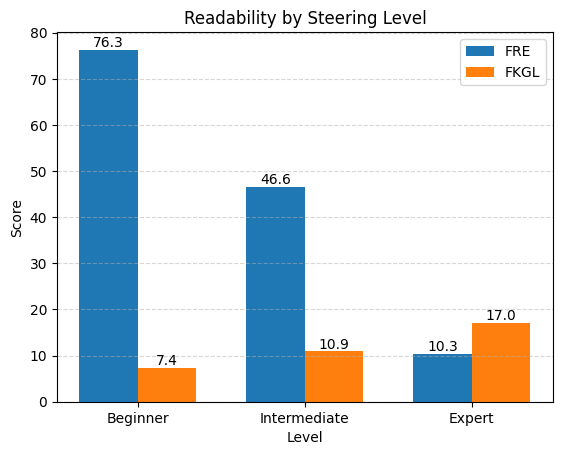

In [6]:
import matplotlib.pyplot as plt
import numpy as np

labels = means.index
x = np.arange(len(labels))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, means["FRE"], width, label="FRE")
bars2 = plt.bar(x + width/2, means["FKGL"], width, label="FKGL")

# labels & title
plt.xlabel("Level")
plt.ylabel("Score")
plt.title("Readability by Steering Level")
plt.xticks(x, labels)
plt.legend()

# 🔥 add values on top (like your image)
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.1f}", ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.1f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [7]:
def make_prompt_baseline(text, level):
    if level == "beginner":
        return f"""Explain this in very simple terms using short sentences:

{text}

Explanation:"""

    elif level == "expert":
        return f"""Give a detailed and technical explanation using precise terminology:

{text}

Explanation:"""

In [12]:
def generate_baseline(prompt, max_new_tokens=120):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # remove prompt
    generated_tokens = output[0][input_len:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True)

In [16]:
levels = ["beginner", "expert"]

baseline_results = []

for i, text in enumerate(INPUT_TEXTS):
    print(f"\n\n===== SAMPLE {i} =====")

    for level in levels:
        output = generate_baseline(make_prompt_baseline(text, level))
        output = clean_output(output)

        fre, fk = readability(output)

        print(f"{level.upper():>10} | FRE: {fre:>6.2f} | FKGL: {fk:>5.2f}")
        print(output[:200], "\n")

        baseline_results.append({
            "id": i,
            "level": level,
            "output": output,
            "fre": fre,
            "fkgl": fk
        })



===== SAMPLE 0 =====
  BEGINNER | FRE:  57.53 | FKGL:  9.21
In some cases, a condition called endometriosis can cause problems in women's bodies. This condition can lead to swelling of the abdomen and damage to the tissues inside the pelvis. When a woman has b 

    EXPERT | FRE:  36.04 | FKGL: 12.85
Endometriosis is a condition where tissue similar to the lining of the uterus grows outside the uterus. In some cases, it can cause inflammation and scarring in other organs such as the liver or ovari 



===== SAMPLE 1 =====
  BEGINNER | FRE:  68.53 | FKGL:  8.52
Imagine you have a big pipe called the hepatic vein in your body. Sometimes, there can be a problem with this pipe where it gets blocked, like when there is a clot inside it. Doctors use special machi 

    EXPERT | FRE:  40.02 | FKGL: 12.83
Budd-Chiari syndrome is a condition where there is a blockage in the liver's veins, which can lead to symptoms such as abdominal pain, jaundice, and swelling of the abdomen. In this particu

In [17]:
df_base = pd.DataFrame(baseline_results)

table_base = df_base.pivot(index="id", columns="level", values=["fre", "fkgl"])
table_base.columns = [f"{lvl}_{metric}" for metric, lvl in table_base.columns]

display(table_base.round(2))

,beginner_fre,expert_fre,beginner_fkgl,expert_fkgl
id,,,,
0,57.53,36.04,9.21,12.85
1,68.53,40.02,8.52,12.83
2,74.27,29.07,6.88,13.63
3,59.49,41.95,9.38,11.98
4,67.52,43.24,8.91,12.05
5,49.23,20.96,13.04,15.26


In [24]:
table_base.to_csv("readability_table_no_sv.csv", index=True)

In [25]:
means_base = df_base.groupby("level")[["fre", "fkgl"]].mean()
print(means_base)

                fre       fkgl
level                         
beginner  62.761056   9.322851
expert    35.211951  13.099150


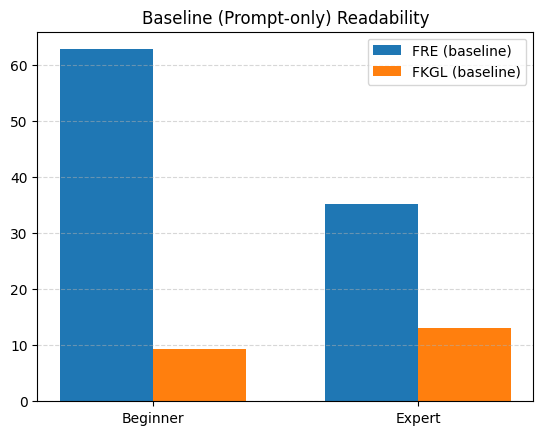

In [20]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Beginner", "Expert"]
x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, means_base["fre"], width, label="FRE (baseline)")
plt.bar(x + width/2, means_base["fkgl"], width, label="FKGL (baseline)")

plt.xticks(x, labels)
plt.title("Baseline (Prompt-only) Readability")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

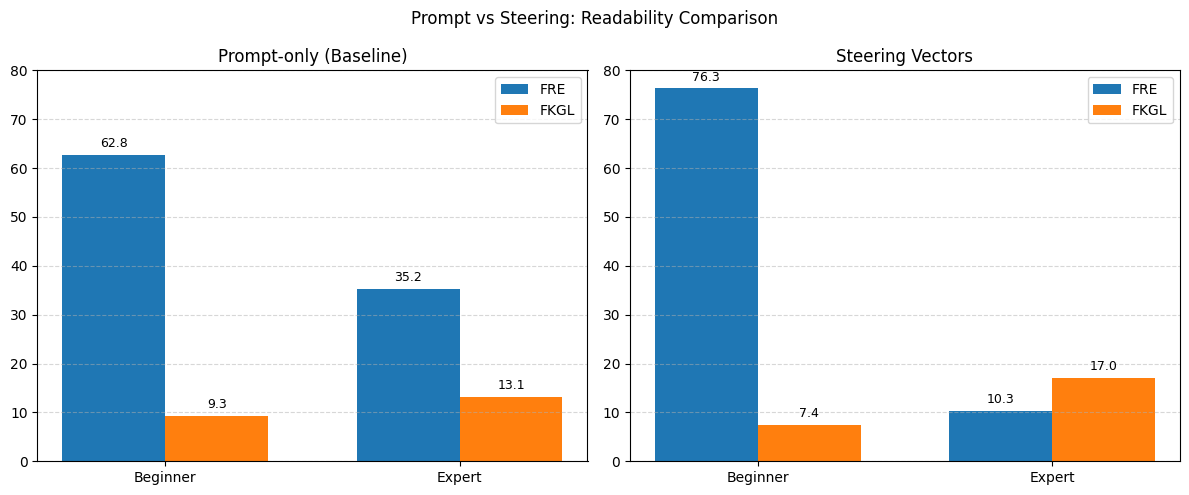

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load both files
df_sv = pd.read_csv("readability_table.csv", index_col=0)
df_base = pd.read_csv("readability_table_no_sv.csv", index_col=0)

# remove mean row if exists
if "mean" in df_sv.index:
    df_sv = df_sv.drop("mean")
if "mean" in df_base.index:
    df_base = df_base.drop("mean")

# compute means
means_sv = {
    "Beginner_FRE": df_sv["beginner_fre"].mean(),
    "Expert_FRE": df_sv["expert_fre"].mean(),
    "Beginner_FKGL": df_sv["beginner_fkgl"].mean(),
    "Expert_FKGL": df_sv["expert_fkgl"].mean(),
}

means_base = {
    "Beginner_FRE": df_base["beginner_fre"].mean(),
    "Expert_FRE": df_base["expert_fre"].mean(),
    "Beginner_FKGL": df_base["beginner_fkgl"].mean(),
    "Expert_FKGL": df_base["expert_fkgl"].mean(),
}

# plotting
labels = ["Beginner", "Expert"]
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔥 helper function to add labels
def add_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

# 🔹 LEFT: Prompt-only
axes[0].bar(x - width/2,
            [means_base["Beginner_FRE"], means_base["Expert_FRE"]],
            width, label="FRE")

axes[0].bar(x + width/2,
            [means_base["Beginner_FKGL"], means_base["Expert_FKGL"]],
            width, label="FKGL")

axes[0].set_title("Prompt-only (Baseline)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 80)  # 🔥 SAME AXIS
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

add_labels(axes[0])  # 🔥 add numbers

# 🔹 RIGHT: Steering
axes[1].bar(x - width/2,
            [means_sv["Beginner_FRE"], means_sv["Expert_FRE"]],
            width, label="FRE")

axes[1].bar(x + width/2,
            [means_sv["Beginner_FKGL"], means_sv["Expert_FKGL"]],
            width, label="FKGL")

axes[1].set_title("Steering Vectors")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 80)  # 🔥 SAME AXIS
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

add_labels(axes[1])  # 🔥 add numbers

plt.suptitle("Prompt vs Steering: Readability Comparison")
plt.tight_layout()
plt.show()